# Credit Scoring Model using Machine Learning

## CodeAlpha Machine Learning Internship

### Objective
Develop a machine learning model to predict whether a loan applicant is likely to default based on demographic, financial, and credit history information.

### Algorithms Used
- Logistic Regression
- Random Forest
- XGBoost (optional)

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 165


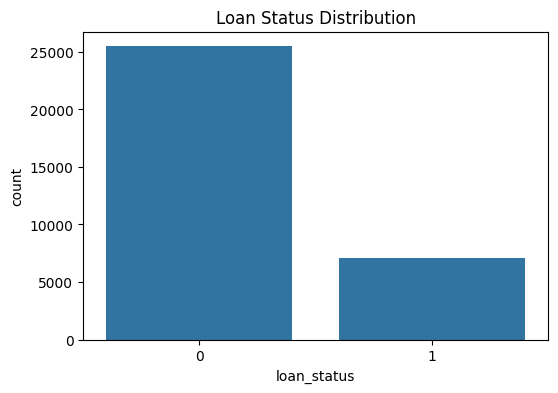

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_status", data=df)

plt.title("Loan Status Distribution")

plt.show()

print(df["loan_status"].value_counts())

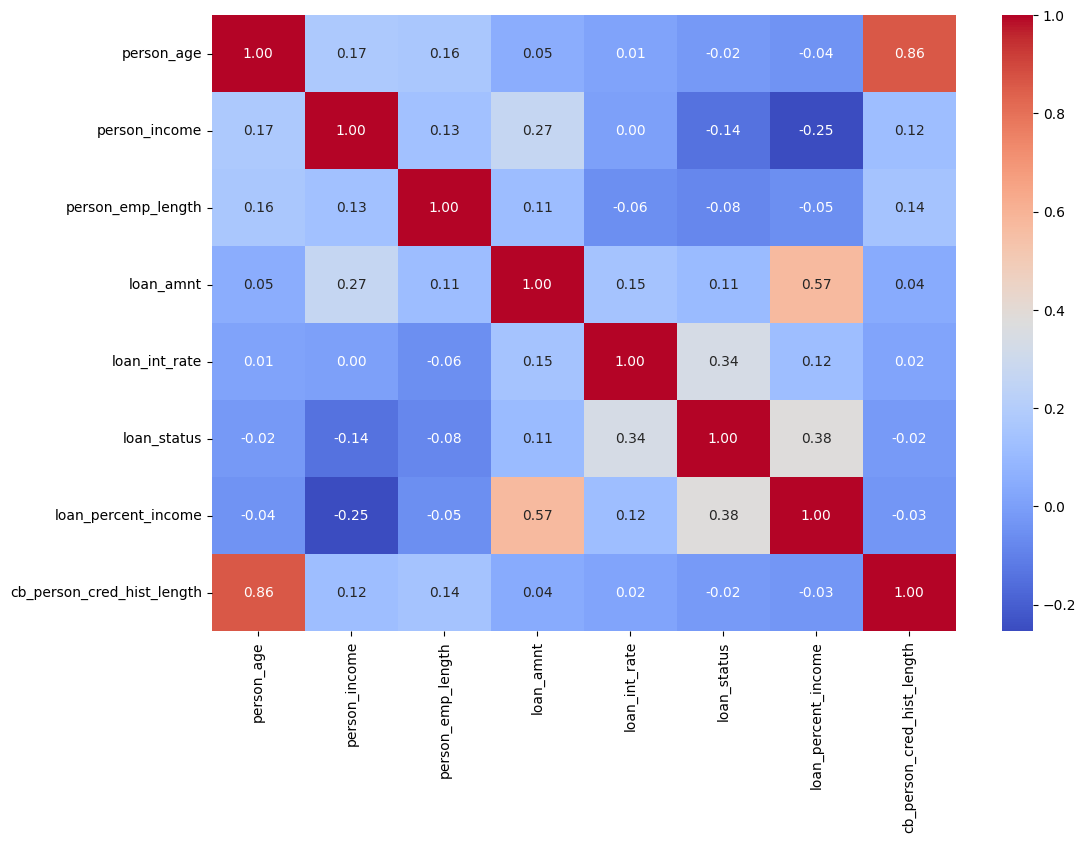

In [9]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [11]:
encoder = LabelEncoder()

categorical = df.select_dtypes(include="object").columns

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [12]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
# Train Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [16]:
print("Logistic Regression Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, log_pred))

print("\nClassification Report\n")
print(classification_report(y_test, log_pred))

Logistic Regression Performance
----------------------------------------
Accuracy : 0.8448672702163572
Precision: 0.7241003271537623
Recall   : 0.4669479606188467
F1 Score : 0.5677640017101325
ROC-AUC  : 0.7086457173064793

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5095
           1       0.72      0.47      0.57      1422

    accuracy                           0.84      6517
   macro avg       0.79      0.71      0.74      6517
weighted avg       0.83      0.84      0.83      6517



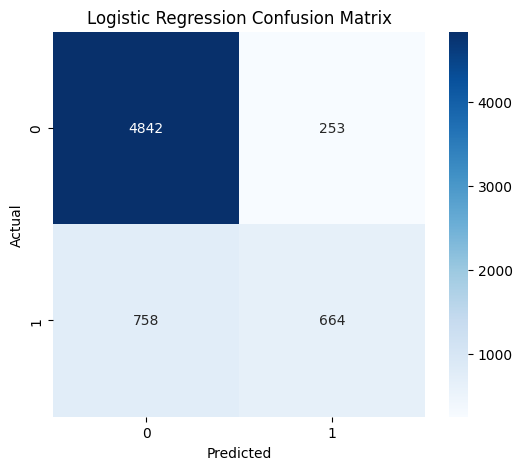

In [17]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [19]:
print("Random Forest Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Performance
----------------------------------------
Accuracy : 0.9307963787018567
Precision: 0.9681774349083896
Recall   : 0.7060478199718706
F1 Score : 0.8165921106140708
ROC-AUC  : 0.8497854408985948

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5095
           1       0.97      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



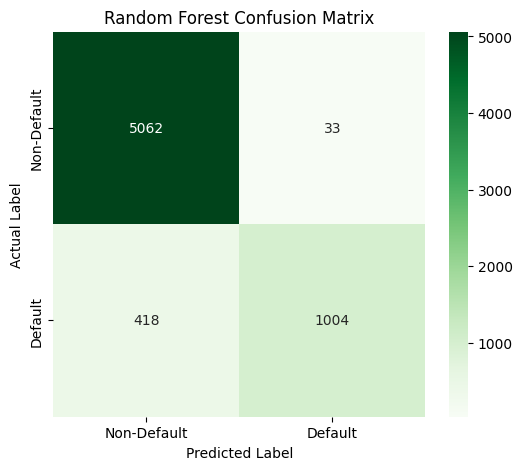

In [28]:
# Random Forest Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Non-Default', 'Default'],
    yticklabels=['Non-Default', 'Default']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [25]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [26]:
print("XGBoost Performance")
print("-"*40)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

XGBoost Performance
----------------------------------------
Accuracy : 0.935246278962713
Precision: 0.9826254826254827
Recall   : 0.7158931082981715
F1 Score : 0.8283157038242474
ROC-AUC  : 0.856180116465082

Classification Report

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5095
           1       0.98      0.72      0.83      1422

    accuracy                           0.94      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.94      0.93      6517



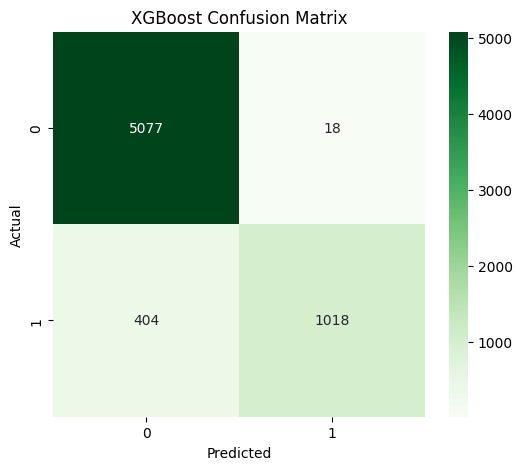

In [27]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [29]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, log_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, xgb_pred)
    ]

})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.935246,0.982625,0.715893,0.828316,0.856180
1,Random Forest,0.930796,0.968177,0.706048,0.816592,0.849785
0,Logistic Regression,0.844867,0.724100,0.466948,0.567764,0.708646


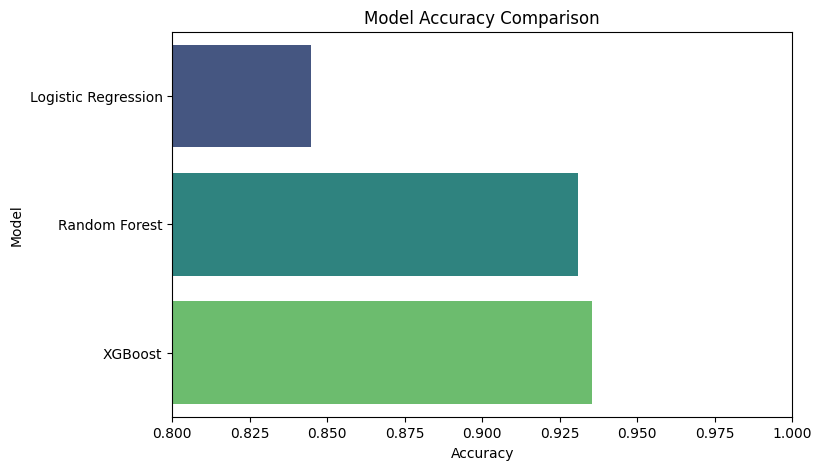

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results,
    palette="viridis"
)

plt.xlim(0.80,1.00)

plt.title("Model Accuracy Comparison")

plt.show()

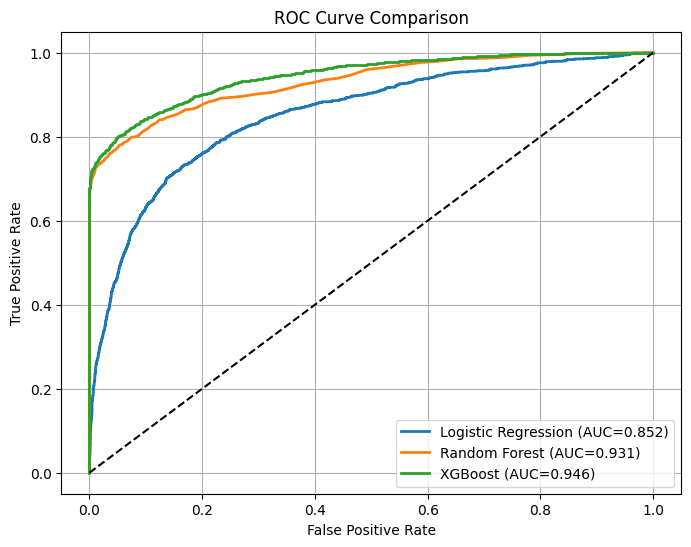

In [31]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,loan_grade,0.330879
8,loan_percent_income,0.193765
2,person_home_ownership,0.179708
4,loan_intent,0.077124
1,person_income,0.074893
6,loan_amnt,0.039132
3,person_emp_length,0.035983
7,loan_int_rate,0.026979
0,person_age,0.017040
9,cb_person_default_on_file,0.013221


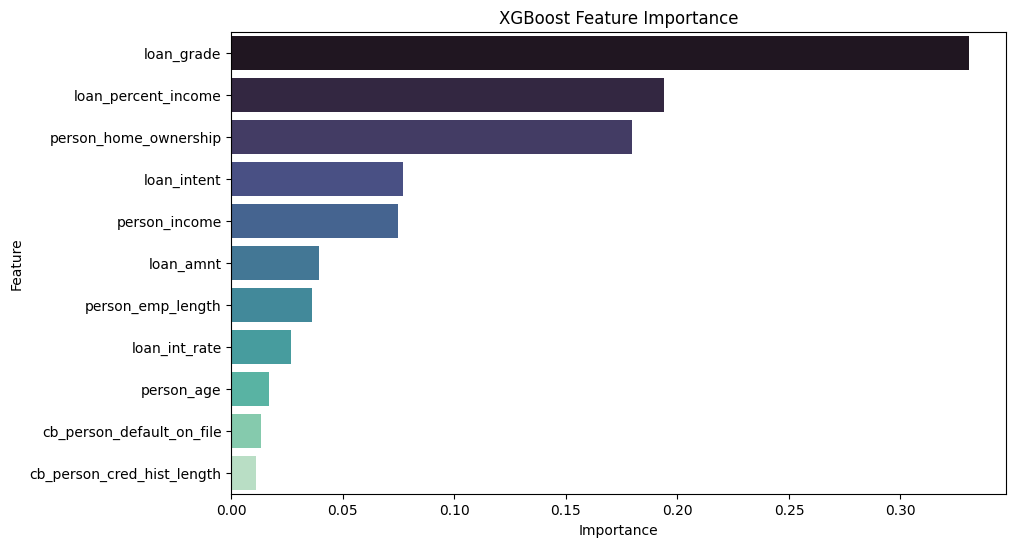

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="mako"
)

plt.title("XGBoost Feature Importance")

plt.show()

In [35]:
sample = [[
    30,          # Age
    65000,       # Income
    2,           # Home Ownership (encoded)
    6,           # Employment Length
    3,           # Loan Intent (encoded)
    2,           # Loan Grade (encoded)
    15000,       # Loan Amount
    11.5,        # Interest Rate
    0.25,        # Loan Percent Income
    0,           # Historical Default
    8            # Credit History Length
]]

sample = scaler.transform(sample)

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("High Credit Risk (Likely to Default)")
else:
    print("Low Credit Risk (Safe Applicant)")

Low Credit Risk (Safe Applicant)


In [34]:
joblib.dump(xgb_model, "credit_scoring_xgboost.pkl")
joblib.dump(scaler, "credit_scaler.pkl")

print("XGBoost model and scaler saved successfully!")

XGBoost model and scaler saved successfully!


# Conclusion

This project developed a Credit Scoring Model to predict whether a loan applicant is likely to default.

## Machine Learning Algorithms
- Logistic Regression
- Random Forest

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The Random Forest model achieved the best overall performance and was selected as the final model. The trained model and scaler were saved for future predictions.

This project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, model evaluation, comparison, and prediction on unseen loan applicants.